In [3]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [4]:
s3_path = "s3://irbnb-project-cloud-computing/Airbnb_clean/airbnb_cleaned.csv"
df = pd.read_csv(s3_path)

print(df.shape)
print(df.head())

(101811, 28)
        id                                              name      host_id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host_name neighbourhood_group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2            unconfirmed     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... number_of_reviews  last_review  \
0  40.64749 -73

In [5]:
feature_cols = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "host_identity_verified",
    "instant_bookable",
    "cancellation_policy",
    "construction_year",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "review_rate_number",
    "calculated_host_listings_count",
    "availability_365",
]

target_col = "price_category"

classification_df = df[feature_cols + [target_col]].copy()
classification_df = classification_df.dropna(subset=[target_col])

X = classification_df[feature_cols]
y = classification_df[target_col]

print("Shape:", classification_df.shape)
print("\nTarget distribution:")
print(y.value_counts())

Shape: (101811, 14)

Target distribution:
price_category
Low       33997
Medium    33933
High      33881
Name: count, dtype: int64


In [6]:
categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "host_identity_verified",
    "instant_bookable",
    "cancellation_policy",
]

numeric_features = [
    "construction_year",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "review_rate_number",
    "calculated_host_listings_count",
    "availability_365",
]

In [7]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (81448, 13)
Test shape: (20363, 13)


# Logistic Regression

In [9]:
log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)

log_reg_model.fit(X_train, y_train)
y_pred_log = log_reg_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 3))
print(
    "Precision:",
    round(precision_score(y_test, y_pred_log, average="weighted"), 3),
)
print(
    "Recall:",
    round(recall_score(y_test, y_pred_log, average="weighted"), 3),
)
print(
    "F1-score:",
    round(f1_score(y_test, y_pred_log, average="weighted"), 3),
)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

c:\Users\Anuska Acharya\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Results
Accuracy: 0.336
Precision: 0.336
Recall: 0.336
F1-score: 0.336

Classification Report:

              precision    recall  f1-score   support

        High       0.34      0.35      0.34      6776
         Low       0.33      0.31      0.32      6800
      Medium       0.33      0.35      0.34      6787

    accuracy                           0.34     20363
   macro avg       0.34      0.34      0.34     20363
weighted avg       0.34      0.34      0.34     20363



# Random Forest Classifier

In [10]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classifier Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print(
    "Precision:",
    round(precision_score(y_test, y_pred_rf, average="weighted"), 3),
)
print(
    "Recall:",
    round(recall_score(y_test, y_pred_rf, average="weighted"), 3),
)
print(
    "F1-score:",
    round(f1_score(y_test, y_pred_rf, average="weighted"), 3),
)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Results
Accuracy: 0.503
Precision: 0.503
Recall: 0.503
F1-score: 0.503

Classification Report:

              precision    recall  f1-score   support

        High       0.50      0.52      0.51      6776
         Low       0.50      0.50      0.50      6800
      Medium       0.50      0.49      0.50      6787

    accuracy                           0.50     20363
   macro avg       0.50      0.50      0.50     20363
weighted avg       0.50      0.50      0.50     20363



In [11]:
classification_results = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest Classifier"],
        "Accuracy": [
            accuracy_score(y_test, y_pred_log),
            accuracy_score(y_test, y_pred_rf),
        ],
        "Precision": [
            precision_score(y_test, y_pred_log, average="weighted"),
            precision_score(y_test, y_pred_rf, average="weighted"),
        ],
        "Recall": [
            recall_score(y_test, y_pred_log, average="weighted"),
            recall_score(y_test, y_pred_rf, average="weighted"),
        ],
        "F1_score": [
            f1_score(y_test, y_pred_log, average="weighted"),
            f1_score(y_test, y_pred_rf, average="weighted"),
        ],
    }
)

classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1_score
0,Logistic Regression,0.336,0.336,0.336,0.336
1,Random Forest Classifier,0.503,0.503,0.503,0.503


In [12]:
print("Logistic Regression Confusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("\nRandom Forest Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Logistic Regression Confusion Matrix
[[2351 2101 2324]
 [2288 2120 2392]
 [2275 2145 2367]]

Random Forest Confusion Matrix
[[3527 1670 1579]
 [1711 3378 1711]
 [1756 1694 3337]]


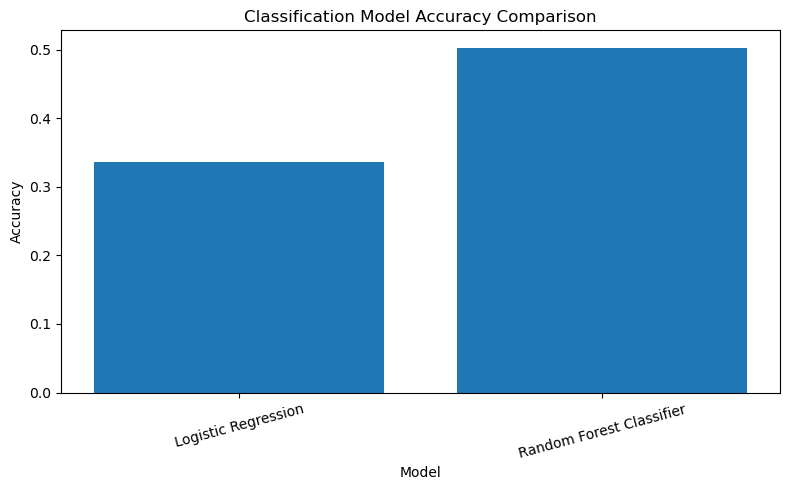

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

classification_results = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest Classifier"],
        "Accuracy": [0.336, 0.503],
        "F1_score": [0.336, 0.503],
    }
)

plt.figure(figsize=(8, 5))
plt.bar(classification_results["Model"], classification_results["Accuracy"])
plt.title("Classification Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

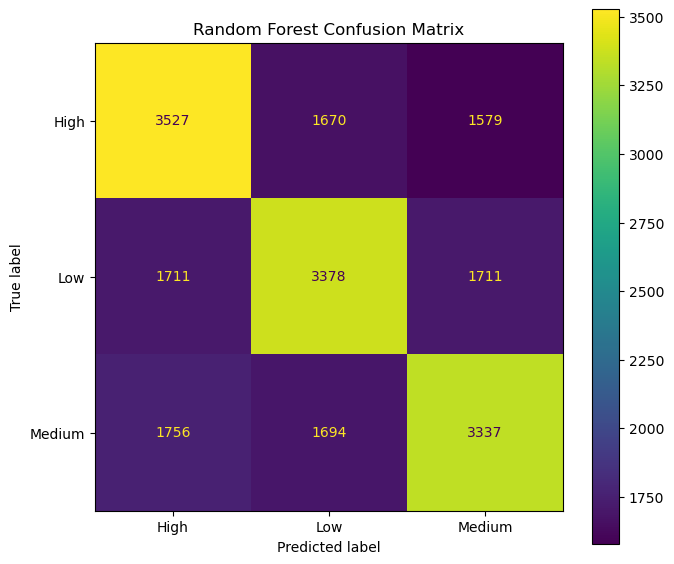

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

rf_cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=rf_model.classes_,
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

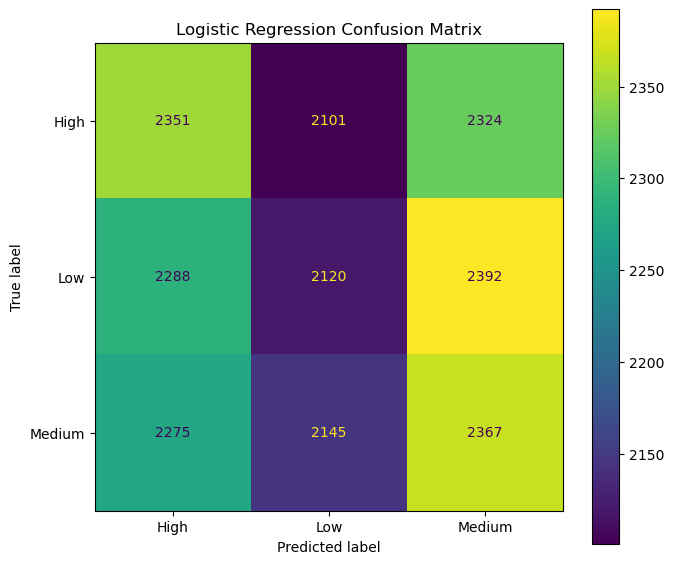

In [15]:
log_cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=log_cm,
    display_labels=log_reg_model.classes_,
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()